# Denver CPI Trends Analysis

Consumer Price Index analysis for Denver/Boulder/Greeley metro area.
- **Annual trends**: Year-over-year CPI levels
- **Semi-annual trends**: Sub-annual granularity (BLS publishes semi-annual for Denver region)

## Setup & Data Loading

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)

import matplotlib.pyplot as plt
from pathlib import Path

# Resolve data path: Kaggle first, then local
KAGGLE_PATH = Path("/kaggle/input/datasets/organizations/bls/denver-cpi/Consumer_Price_Index_in_Denver.csv")
LOCAL_PATH = Path("data/Consumer_Price_Index_in_Denver.csv")

if KAGGLE_PATH.exists():
    csv_path = KAGGLE_PATH
    print(f"Using Kaggle path: {csv_path}")
else:
    csv_path = LOCAL_PATH
    if not csv_path.exists():
        csv_path = Path.cwd() / "data" / "Consumer_Price_Index_in_Denver.csv"
    print(f"Using local path: {csv_path}")

df_raw = pd.read_csv(csv_path)

Using local path: data/Consumer_Price_Index_in_Denver.csv


In [2]:
# Filter Denver region + headline CPI (type=1: CPI-U all items)
denver = df_raw[(df_raw["dataRegion"] == "CO") & (df_raw["type"] == 1)].copy()
denver.head(10)

,stateFips,area,areaType,period,periodYear,periodType,periodTypeDescription,cpi,title,type,source,cpiSourceDescription,percentChangeYear,percentChangeMonth,dataRegion,areaName,areaDescription
8,8,2,24,6,1996,7,Semi-Annual,152.0,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.5,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
17,8,2,24,12,1996,7,Semi-Annual,154.2,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.5,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
26,8,2,24,0,1997,1,Annual,158.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.3,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
35,8,2,24,6,1997,7,Semi-Annual,157.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.4,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
52,8,2,24,12,1997,7,Semi-Annual,159.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.2,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
61,8,2,24,0,1998,1,Annual,161.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.4,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
70,8,2,24,6,1998,7,Semi-Annual,160.5,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.2,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
79,8,2,24,12,1998,7,Semi-Annual,163.3,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.6,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
88,8,2,24,0,1999,1,Annual,166.6,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.9,0.0,CO,Denver/Boulder/Greeley,Denver CPI region
313,8,2,24,6,1999,7,Semi-Annual,165.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.9,0.0,CO,Denver/Boulder/Greeley,Denver CPI region


In [3]:
# Data overview: period types available for Denver
denver.groupby(["periodType", "periodTypeDescription"]).size()

periodType  periodTypeDescription
1           Annual                   18
7           Semi-Annual              37
dtype: int64

## Annual Trends

In [4]:
# Annual data: periodType 1 = Annual
annual = denver[denver["periodType"] == 1].copy()
annual = annual.groupby("periodYear", as_index=False)["cpi"].mean()
annual = annual.sort_values("periodYear").reset_index(drop=True)

# YoY percent change
annual["pct_change_yoy"] = annual["cpi"].pct_change() * 100
annual.head(15)

,periodYear,cpi,pct_change_yoy
0,1995,147.9,NaN
1,1996,153.1,3.515889
2,1997,158.1,3.265839
3,1998,161.9,2.403542
4,1999,166.6,2.903027
5,2000,173.2,3.961585
6,2001,181.3,4.676674
7,2002,184.8,1.930502
8,2003,186.8,1.082251
9,2004,187.0,0.107066


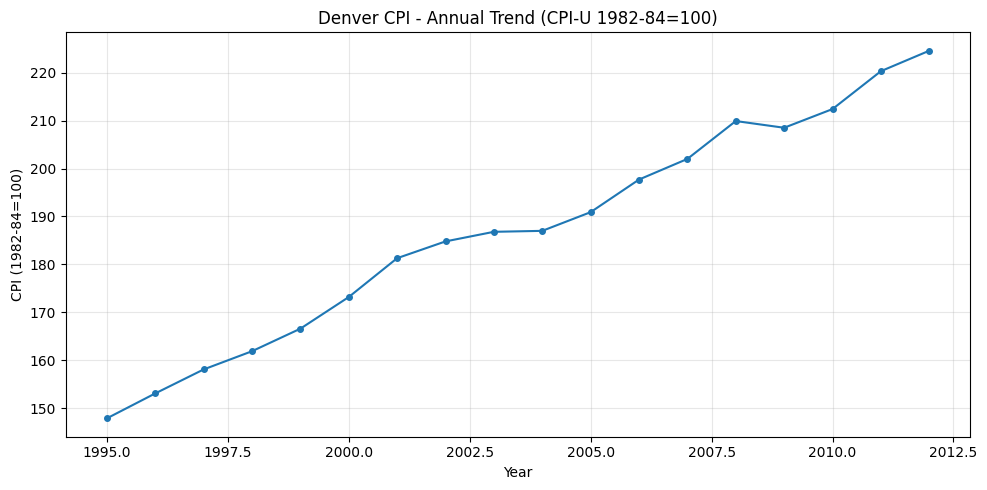

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(annual["periodYear"], annual["cpi"], marker="o", markersize=4)
ax.set_xlabel("Year")
ax.set_ylabel("CPI (1982-84=100)")
ax.set_title("Denver CPI - Annual Trend (CPI-U 1982-84=100)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

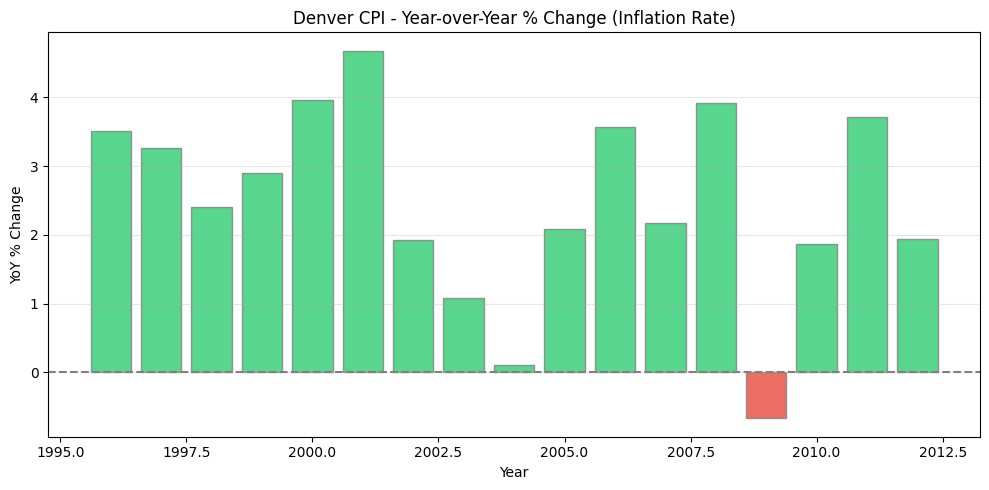

In [6]:
# Year-over-year inflation rate
yoy = annual.dropna(subset=["pct_change_yoy"])
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in yoy["pct_change_yoy"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yoy["periodYear"], yoy["pct_change_yoy"], color=colors, edgecolor="gray", alpha=0.8)
ax.axhline(y=0, color="gray", linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("YoY % Change")
ax.set_title("Denver CPI - Year-over-Year % Change (Inflation Rate)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Semi-Annual (Sub-Annual) Trends

In [7]:
# Semi-annual data: periodType 7, period 6 = H1, period 12 = H2
semi = denver[denver["periodType"] == 7].copy()
semi["half"] = semi["period"].map({6: "H1 (Jan-Jun)", 12: "H2 (Jul-Dec)"})
semi["period_label"] = semi["periodYear"].astype(str) + " " + semi["half"]
semi = semi.sort_values(["periodYear", "period"]).reset_index(drop=True)

# Quarter-like label for display (H1/H2)
semi["year_half"] = semi["periodYear"].astype(str) + "-" + semi["period"].astype(str)
semi.head(10)

,stateFips,area,areaType,period,periodYear,periodType,periodTypeDescription,cpi,title,type,source,cpiSourceDescription,percentChangeYear,percentChangeMonth,dataRegion,areaName,areaDescription,half,period_label,year_half
0,8,2,24,6,1995,7,Semi-Annual,146.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",4.9,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H1 (Jan-Jun),1995 H1 (Jan-Jun),1995-6
1,8,2,24,12,1995,7,Semi-Annual,149.0,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.8,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H2 (Jul-Dec),1995 H2 (Jul-Dec),1995-12
2,8,2,24,6,1996,7,Semi-Annual,152.0,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.5,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H1 (Jan-Jun),1996 H1 (Jan-Jun),1996-6
3,8,2,24,12,1996,7,Semi-Annual,154.2,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.5,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H2 (Jul-Dec),1996 H2 (Jul-Dec),1996-12
4,8,2,24,6,1997,7,Semi-Annual,157.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.4,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H1 (Jan-Jun),1997 H1 (Jan-Jun),1997-6
5,8,2,24,12,1997,7,Semi-Annual,159.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.2,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H2 (Jul-Dec),1997 H2 (Jul-Dec),1997-12
6,8,2,24,6,1998,7,Semi-Annual,160.5,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.2,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H1 (Jan-Jun),1998 H1 (Jan-Jun),1998-6
7,8,2,24,12,1998,7,Semi-Annual,163.3,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.6,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H2 (Jul-Dec),1998 H2 (Jul-Dec),1998-12
8,8,2,24,6,1999,7,Semi-Annual,165.1,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",2.9,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H1 (Jan-Jun),1999 H1 (Jan-Jun),1999-6
9,8,2,24,12,1999,7,Semi-Annual,168.2,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",3.0,0.0,CO,Denver/Boulder/Greeley,Denver CPI region,H2 (Jul-Dec),1999 H2 (Jul-Dec),1999-12


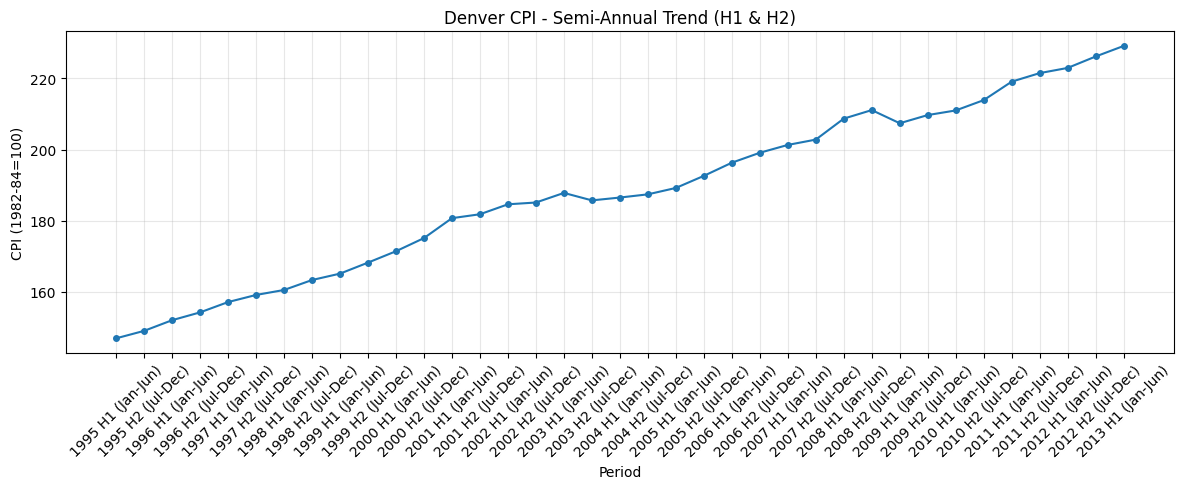

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(semi["period_label"], semi["cpi"], marker="o", markersize=4)
ax.set_xlabel("Period")
ax.set_ylabel("CPI (1982-84=100)")
ax.set_title("Denver CPI - Semi-Annual Trend (H1 & H2)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

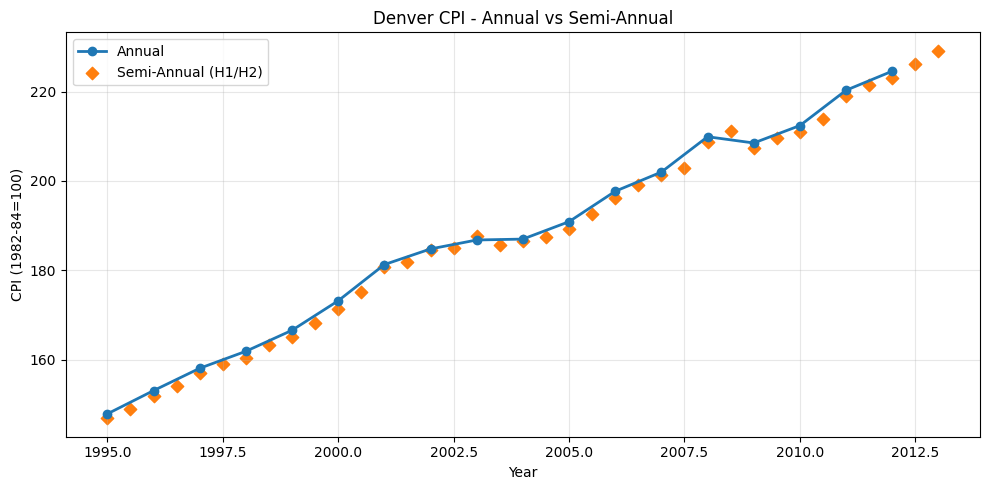

In [9]:
# Combined: annual + semi-annual on same chart
semi["x_pos"] = semi["periodYear"] + (semi["period"] / 12 - 0.5)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(annual["periodYear"], annual["cpi"], "o-", label="Annual", color="#1f77b4", linewidth=2, markersize=6)
ax.scatter(semi["x_pos"], semi["cpi"], label="Semi-Annual (H1/H2)", color="#ff7f0e", marker="D", s=40)
ax.set_xlabel("Year")
ax.set_ylabel("CPI (1982-84=100)")
ax.set_title("Denver CPI - Annual vs Semi-Annual")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()